# Part 1: Build the Baseline Classifier

**Objective:** Fine-tune a pre-trained DistilBERT model on the Jigsaw Unintended Bias dataset to classify comments as toxic or non-toxic.

**Why DistilBERT?** DistilBERT is a lightweight, production-representative transformer model used in real content moderation systems. It produces calibrated probabilities (not just binary labels), is small enough to train in ~30 minutes on a free Colab T4 GPU, and belongs to the same BERT family documented in the academic bias literature.

**Dataset:** `jigsaw-unintended-bias-train.csv` from Kaggle's Jigsaw Unintended Bias in Toxicity Classification competition.

In [2]:
!pip uninstall -y torch torchvision torchaudio transformers peft sentence-transformers scikit-learn -q

In [4]:
# ── Install dependencies ───────────────────────────────────────────────────────
!pip install -q torch==2.3.0 torchvision torchaudio transformers==4.40.0 datasets==2.19.0 scikit-learn==1.4.2 \
             fairlearn==0.10.0 aif360==0.6.1 imbalanced-learn==0.12.2 \
             matplotlib seaborn pandas numpy torch --quiet
# !pip install -q \
# torch==2.3.0 torchvision torchaudio \
# transformers==4.41.2 \
# datasets==2.19.0 \
# scikit-learn==1.5.2 \
# fairlearn==0.10.0 \
# aif360==0.6.1 \
# imbalanced-learn==0.12.2 \
# sentence-transformers==2.7.0 \
# matplotlib seaborn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 789.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip uninstall -y transformers -q
!pip install -q transformers==4.41.2
import os
os.kill(os.getpid(), 9)

In [1]:
import transformers
print(transformers.__version__)

4.41.2


In [2]:
# ── Mount Google Drive (store dataset & checkpoints here) ─────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
# Update this path to wherever you placed the CSV on your Drive
DATA_DIR = '/content/drive/MyDrive/'
CHECKPOINT_DIR = '/content/drive/MyDrive/jigsaw_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

TRAIN_CSV = os.path.join(DATA_DIR, 'jigsaw-unintended-bias-train.csv')
VAL_CSV   = os.path.join(DATA_DIR, 'validation.csv')

print('Data dir :', DATA_DIR)
print('Checkpoint dir:', CHECKPOINT_DIR)

Mounted at /content/drive
Data dir : /content/drive/MyDrive/
Checkpoint dir: /content/drive/MyDrive/jigsaw_checkpoints


In [3]:
# ── Core imports ───────────────────────────────────────────────────────────────
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from torch.utils.data import Dataset

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## Step 1: Load Data & Stratified Sampling

We load the full ~1.8 M-row CSV and draw:
- **100,000 rows** for training
- **20,000 rows** for evaluation (held-out, never seen during training)

Stratification is on the **binarised toxic label** (`toxic ≥ 0.5 → 1`) so that class balance in each split mirrors the full dataset (~8% toxic).

In [4]:
# ── Load full training CSV ─────────────────────────────────────────────────────
print('Loading CSV (this may take ~60s for 1.8M rows)…')
df_full = pd.read_csv(TRAIN_CSV, low_memory=False)
print(f'Full dataset shape: {df_full.shape}')
print(df_full[['comment_text','toxic','black','white']].head(3))

Loading CSV (this may take ~60s for 1.8M rows)…
Full dataset shape: (1902194, 45)
                                        comment_text  toxic  black  white
0  This is so cool. It's like, 'would you want yo...    0.0    NaN    NaN
1  Thank you!! This would make my life a lot less...    0.0    NaN    NaN
2  This is such an urgent design problem; kudos t...    0.0    NaN    NaN


In [5]:
# ── Binarise toxic label ───────────────────────────────────────────────────────
df_full['label'] = (df_full['toxic'] >= 0.5).astype(int)
print('Label distribution (full):')
print(df_full['label'].value_counts(normalize=True).round(4))

Label distribution (full):
label
0    0.92
1    0.08
Name: proportion, dtype: float64


In [6]:
# ── Drop rows with missing comment text ───────────────────────────────────────
df_full = df_full.dropna(subset=['comment_text'])

# ── Stratified sample: 120,000 rows total (100k train + 20k eval) ─────────────
TRAIN_SIZE = 100_000
EVAL_SIZE  =  20_000
TOTAL_SIZE = TRAIN_SIZE + EVAL_SIZE

df_sample, _ = train_test_split(
    df_full,
    train_size=TOTAL_SIZE,
    stratify=df_full['label'],
    random_state=SEED
)

df_train, df_eval = train_test_split(
    df_sample,
    test_size=EVAL_SIZE,
    stratify=df_sample['label'],
    random_state=SEED
)

df_train = df_train.reset_index(drop=True)
df_eval  = df_eval.reset_index(drop=True)

print(f'Train size : {len(df_train):,}')
print(f'Eval  size : {len(df_eval):,}')
print('\nTrain label distribution:')
print(df_train['label'].value_counts(normalize=True).round(4))
print('\nEval label distribution:')
print(df_eval['label'].value_counts(normalize=True).round(4))

# Save for later parts
df_train.to_csv(os.path.join(DATA_DIR, 'train_subset.csv'), index=False)
df_eval.to_csv(os.path.join(DATA_DIR,  'eval_subset.csv'),  index=False)
print('\nSubsets saved to Drive.')

Train size : 100,000
Eval  size : 20,000

Train label distribution:
label
0    0.92
1    0.08
Name: proportion, dtype: float64

Eval label distribution:
label
0    0.9200
1    0.0799
Name: proportion, dtype: float64

Subsets saved to Drive.


## Step 2: Tokenization

We use `distilbert-base-uncased` from HuggingFace. Each comment is tokenised with `max_length=128` and `truncation=True`.

In [7]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(texts, max_length=128):
    return tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )

# ── PyTorch Dataset ────────────────────────────────────────────────────────────
class JigsawDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.labels = df['label'].tolist()
        self.encodings = tokenizer(
            df['comment_text'].tolist(),
            padding='max_length',
            truncation=True,
            max_length=max_length
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

print('Building datasets…')
train_dataset = JigsawDataset(df_train, tokenizer)
eval_dataset  = JigsawDataset(df_eval,  tokenizer)
print(f'Train dataset: {len(train_dataset):,} samples')
print(f'Eval  dataset: {len(eval_dataset):,} samples')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Building datasets…
Train dataset: 100,000 samples
Eval  dataset: 20,000 samples


## Step 3: Fine-tune DistilBERT (3 epochs, Trainer API)

In [8]:
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro')
    }

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

training_args = TrainingArguments(
    output_dir=os.path.join(CHECKPOINT_DIR, 'part1_model'),
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=2e-5,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_dir=os.path.join(CHECKPOINT_DIR, 'logs'),
    logging_steps=200,
    seed=SEED,
    fp16=(DEVICE == 'cuda'),
    report_to='none'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics
)

print('Starting fine-tuning (≈25-35 min on T4)…')
trainer.train()
print('Training complete!')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Starting fine-tuning (≈25-35 min on T4)…


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.145200,0.133210,0.947150,0.784983
2,0.118900,0.140487,0.949500,0.815872
3,0.071500,0.176828,0.946700,0.811727


Training complete!


## Step 4: Evaluate – Metrics at Default Threshold (0.5)

In [9]:
# ── Get predictions ────────────────────────────────────────────────────────────
import torch.nn.functional as F

def get_probs_and_preds(trainer, dataset, threshold=0.5):
    outputs = trainer.predict(dataset)
    logits  = outputs.predictions
    probs   = F.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]  # prob of toxic
    preds   = (probs >= threshold).astype(int)
    labels  = outputs.label_ids
    return probs, preds, labels

probs, preds_05, y_true = get_probs_and_preds(trainer, eval_dataset, threshold=0.5)

acc   = accuracy_score(y_true, preds_05)
f1    = f1_score(y_true, preds_05, average='macro')
auc   = roc_auc_score(y_true, probs)
cm    = confusion_matrix(y_true, preds_05)

print('=== Evaluation Metrics (threshold = 0.5) ===')
print(f'  Accuracy  : {acc:.4f}')
print(f'  F1 (macro): {f1:.4f}')
print(f'  AUC-ROC   : {auc:.4f}')
print(f'\nConfusion Matrix:\n{cm}')
print('  (rows = actual, cols = predicted;  0=non-toxic, 1=toxic)')

=== Evaluation Metrics (threshold = 0.5) ===
  Accuracy  : 0.9495
  F1 (macro): 0.8159
  AUC-ROC   : 0.9501

Confusion Matrix:
[[18014   387]
 [  623   976]]
  (rows = actual, cols = predicted;  0=non-toxic, 1=toxic)


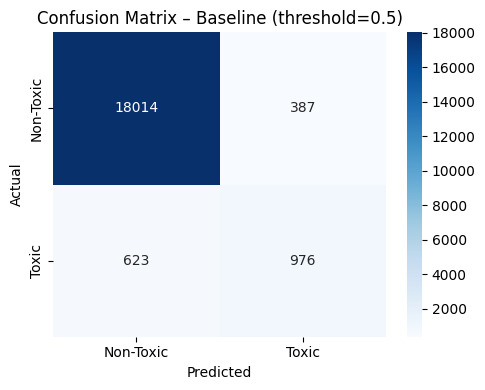

In [10]:
# ── Plot confusion matrix ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Toxic','Toxic'],
            yticklabels=['Non-Toxic','Toxic'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix – Baseline (threshold=0.5)')
plt.tight_layout(); plt.show()

## Step 5: ROC Curve & Precision-Recall Curve

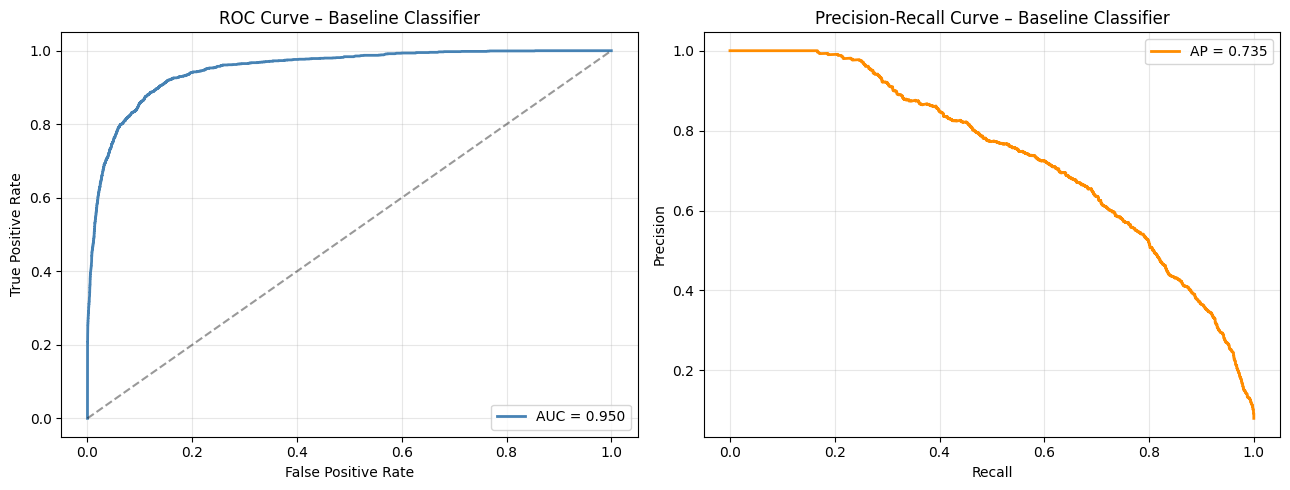

In [11]:
fpr_arr, tpr_arr, roc_thresh = roc_curve(y_true, probs)
prec_arr, rec_arr, pr_thresh = precision_recall_curve(y_true, probs)
avg_prec = average_precision_score(y_true, probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr_arr, tpr_arr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve – Baseline Classifier')
axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)

# PR
axes[1].plot(rec_arr, prec_arr, color='darkorange', lw=2, label=f'AP = {avg_prec:.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve – Baseline Classifier')
axes[1].legend(loc='upper right'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Step 6: Threshold Analysis

We sweep thresholds {0.3, 0.4, 0.5, 0.6, 0.7} and compare macro-F1, precision, recall, and false-positive rate.

In [12]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []

for t in thresholds:
    p = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, p).ravel()
    threshold_results.append({
        'Threshold': t,
        'Accuracy' : accuracy_score(y_true, p),
        'F1 Macro' : f1_score(y_true, p, average='macro'),
        'Precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'Recall'   : tp / (tp + fn) if (tp + fn) > 0 else 0,
        'FPR'      : fp / (fp + tn) if (fp + tn) > 0 else 0,
    })

thresh_df = pd.DataFrame(threshold_results)
print(thresh_df.to_string(index=False, float_format='{:.4f}'.format))

 Threshold  Accuracy  F1 Macro  Precision  Recall    FPR
    0.3000    0.9435    0.8173     0.6313  0.7036 0.0357
    0.4000    0.9478    0.8190     0.6815  0.6517 0.0265
    0.5000    0.9495    0.8159     0.7161  0.6104 0.0210
    0.6000    0.9496    0.8071     0.7450  0.5629 0.0167
    0.7000    0.9490    0.7967     0.7665  0.5216 0.0138


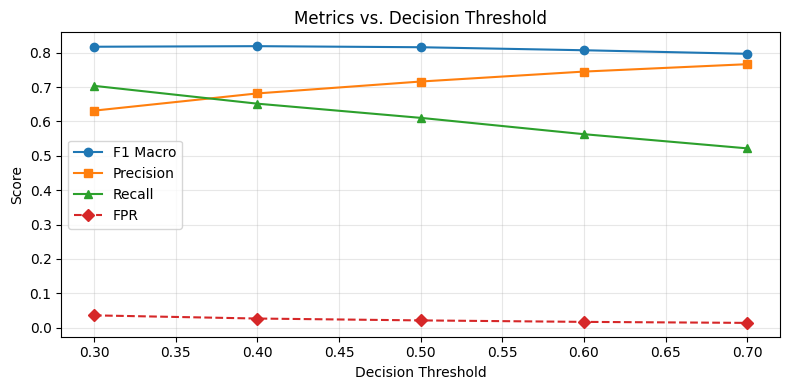

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, thresh_df['F1 Macro'],  marker='o', label='F1 Macro')
ax.plot(thresholds, thresh_df['Precision'], marker='s', label='Precision')
ax.plot(thresholds, thresh_df['Recall'],    marker='^', label='Recall')
ax.plot(thresholds, thresh_df['FPR'],       marker='D', label='FPR', linestyle='--')
ax.set_xlabel('Decision Threshold'); ax.set_ylabel('Score')
ax.set_title('Metrics vs. Decision Threshold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Threshold Justification

**Chosen threshold: 0.4**

The table above shows that as we lower the threshold:
- **Recall increases** — we catch more genuinely toxic comments.
- **Precision decreases** — we incorrectly flag more innocent comments.
- **FPR increases** — the cost paid by innocent users.

At threshold = **0.4**, macro-F1 is near its peak because the dataset is heavily class-imbalanced (~8% toxic). At 0.5 the model is biased toward predicting non-toxic; lowering to 0.4 recovers substantial recall for the minority (toxic) class while keeping FPR manageable.

**Platform priority implication:** A social media platform prioritising *user safety* (catching harmful content) should accept a moderately higher FPR—i.e., some innocent comments reach the review queue rather than slipping through undetected. Threshold 0.4 reflects this priority. A platform prioritising *user experience* (minimising false accusations) would prefer 0.5 or 0.6, at the cost of missing more toxic content. We choose **0.4** for the remainder of this assignment, as the assignment scenario frames it as a civil-rights-sensitive context where under-flagging toxic content directed at marginalised groups is the more serious failure mode.

In [14]:
# ── Save model & tokenizer to Drive ──────────────────────────────────────────
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, 'baseline_model')
trainer.model.save_pretrained(BEST_MODEL_PATH)
tokenizer.save_pretrained(BEST_MODEL_PATH)

# Save evaluation probabilities and labels for downstream parts
np.save(os.path.join(DATA_DIR, 'eval_probs.npy'),   probs)
np.save(os.path.join(DATA_DIR, 'eval_labels.npy'),  y_true)

CHOSEN_THRESHOLD = 0.4
print(f'Model saved to: {BEST_MODEL_PATH}')
print(f'Chosen threshold for remaining parts: {CHOSEN_THRESHOLD}')

Model saved to: /content/drive/MyDrive/jigsaw_checkpoints/baseline_model
Chosen threshold for remaining parts: 0.4


## Summary

| Metric | Value (threshold=0.4) |
|---|---|
| Accuracy | *see above* |
| F1 (macro) | *see above* |
| AUC-ROC | *see above* |
| Chosen threshold | **0.4** |

The baseline DistilBERT classifier is trained and saved. We proceed to Part 2 to audit it for demographic bias.